# 2. Environmental Data Processing by Region

## Overview
This notebook extracts and processes environmental variables (temperature, precipitation) from ERA5-Land reanalysis data at the parish level for the **Área Metropolitana do Porto (AMP)**.

### Inputs
- `environment_input/era5_land_YYYY_QX.nc` – ERA5-Land netCDF files (temperature, precipitation)
- `environment_input/Continente_CAOP2025.gpkg` – Portuguese parish boundaries

### Outputs
- `2_EnvironmentalData_output/month_env_region_AMP.csv` – Monthly environmental data aggregated to parish level

### Key Processing Steps
1. **(Optional)** Download ERA5-Land climate data via CDS API
2. Load and inspect environmental netCDF files
3. Build spatial lookup table mapping parishes to ERA5 grid points
4. Process all quarterly netCDF files
5. Aggregate to monthly statistics per parish
6. Save final integrated environmental dataset

In [19]:
# OPTIONAL: Download ERA5-Land Climate Data

# If you need to download fresh ERA5-Land data:
# 1. Register at: https://cds.climate.copernicus.eu
# 2. Replace <YOUR_KEY> with your CDS API key
# 3. Uncomment and run the code below

# import cdsapi
# 
# client = cdsapi.Client(url='https://cds.climate.copernicus.eu/api', key='<YOUR_KEY>')
# 
# dataset = 'reanalysis-era5-land'
# area = [41.35, -8.9, 40.8, -8.1]  # AMP bounding box [N, W, S, E]
# variables = ['2m_temperature', 'total_precipitation']
# days = [f"{d:02d}" for d in range(1, 32)]
# times = [f"{h:02d}:00" for h in range(24)]
# 
# quarters = {'Q1': ['01', '02', '03'], 'Q2': ['04', '05', '06'], 
#             'Q3': ['07', '08', '09'], 'Q4': ['10', '11', '12']}
# years = ['2020', '2021', '2022', '2023', '2024', '2025']
# 
# for year in years:
#     for q_name, months in quarters.items():
#         request = {
#             'variable': variables,
#             'year': year,
#             'month': months,
#             'day': days,
#             'time': times,
#             'data_format': 'netcdf',
#             'download_format': 'unarchived',
#             'area': area
#         }
#         target_file = f"environment_input/era5_land_{year}_{q_name}.nc"
#         client.retrieve(dataset, request, target_file)
#         print(f"Downloaded: {target_file}")

In [20]:
# SECTION 1: Load & Inspect Data

# %pip install netcdf4
import pandas as pd
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import os


output_dir = '2_EnvironmentalData_output'
os.makedirs(output_dir, exist_ok=True)

print("Loading Portuguese administrative regions...")
regions = gpd.read_file(
    "environment_input/Continente_CAOP2025.gpkg",
    layer="cont_freguesias"
)

print("Loading ERA5-Land sample file...")
ds = xr.open_dataset('environment_input/era5_land_2025_Q1.nc')
print(f"Dataset dimensions: {ds.dims}")
print(f"Variables: {list(ds.data_vars)}")

# Preview the data structure
ds_small = ds[['t2m', 'tp']].mean(dim='valid_time')
df_env = ds_small.to_dataframe().reset_index()

# Convert temperature from Kelvin to Celsius
df_env['t2m'] = pd.to_numeric(df_env['t2m'], errors='coerce') - 273.15
df_env['tp'] = pd.to_numeric(df_env['tp'], errors='coerce')
df_env = df_env.dropna(subset=['t2m', 'tp', 'longitude', 'latitude'])

# Standardize longitude (convert 0-360 to -180-180)
if df_env['longitude'].max() > 180:
    df_env['longitude'] = df_env['longitude'].apply(lambda x: x - 360 if x > 180 else x)

print(f"\nTemperature range: {df_env['t2m'].min():.2f}°C to {df_env['t2m'].max():.2f}°C")
print(f"Precipitation range: {df_env['tp'].min():.4f} to {df_env['tp'].max():.4f} mm")


Loading Portuguese administrative regions...
Loading ERA5-Land sample file...
Dataset dimensions: FrozenMappingWarningOnValuesAccess({'valid_time': 2160, 'latitude': 6, 'longitude': 9})
Variables: ['t2m', 'tp']

Temperature range: 7.88°C to 11.58°C
Precipitation range: 0.0030 to 0.0038 mm


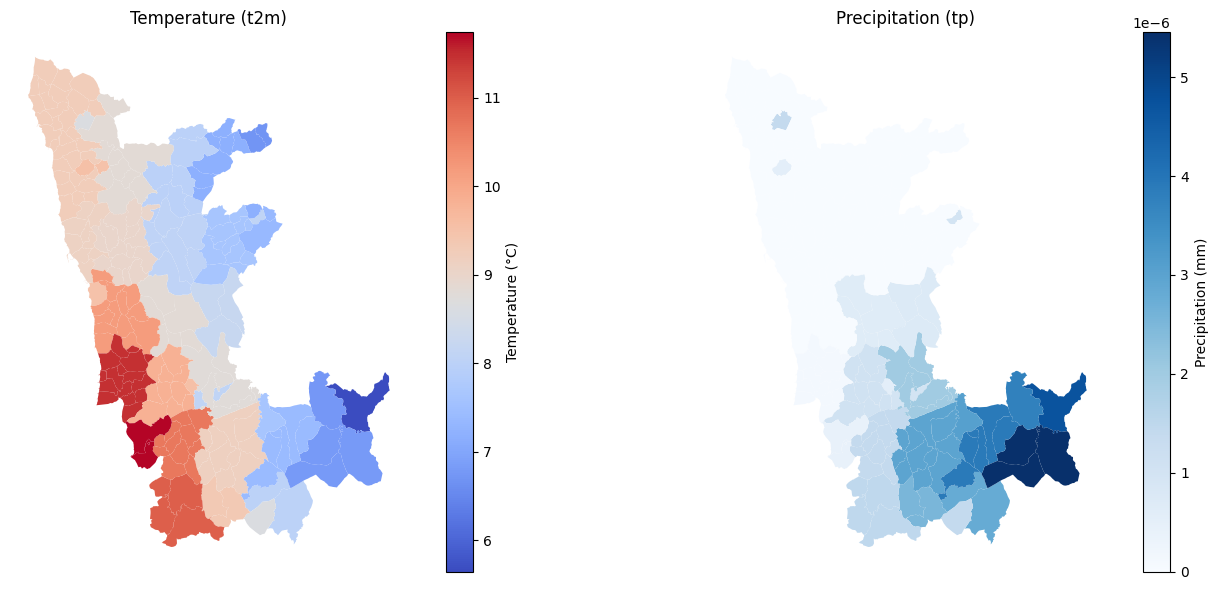

In [21]:
# SECTION 1.1: Plot temperature and precipitation maps for January 1, 2025

ds_jan1 = ds[['t2m', 'tp']].sel(valid_time='2025-01-01T18:00:00')
df_jan1 = ds_jan1.to_dataframe().reset_index()

df_jan1['t2m'] = pd.to_numeric(df_jan1['t2m'], errors='coerce') - 273.15
df_jan1['tp'] = pd.to_numeric(df_jan1['tp'], errors='coerce')
df_jan1 = df_jan1.dropna(subset=['t2m', 'tp', 'longitude', 'latitude'])
if df_jan1['longitude'].max() > 180:
    df_jan1['longitude'] = df_jan1['longitude'].apply(lambda x: x - 360 if x > 180 else x)

gdf_jan1 = gpd.GeoDataFrame(
    df_jan1, 
    geometry=gpd.points_from_xy(df_jan1['longitude'], df_jan1['latitude']), 
    crs="EPSG:4326"
).to_crs("EPSG:3763")

porto_regions = regions[regions['nuts3'] == 'Área Metropolitana do Porto']
merged_gdf_jan1 = gpd.sjoin_nearest(porto_regions, gdf_jan1, how="left")
map_data_jan1 = merged_gdf_jan1.dissolve(by='freguesia', aggfunc={'t2m': 'mean', 'tp': 'mean'}).reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

map_data_jan1.plot(column='t2m', ax=ax1, legend=True, cmap='coolwarm', 
              missing_kwds={'color': 'lightgrey'}, legend_kwds={'label': "Temperature (°C)"})
ax1.set_title("Temperature (t2m)")
ax1.axis('off')

map_data_jan1.plot(column='tp', ax=ax2, legend=True, cmap='Blues', 
              missing_kwds={'color': 'lightgrey'}, legend_kwds={'label': "Precipitation (mm)"})
ax2.set_title("Precipitation (tp)")
ax2.axis('off')

plt.tight_layout()
plt.show()

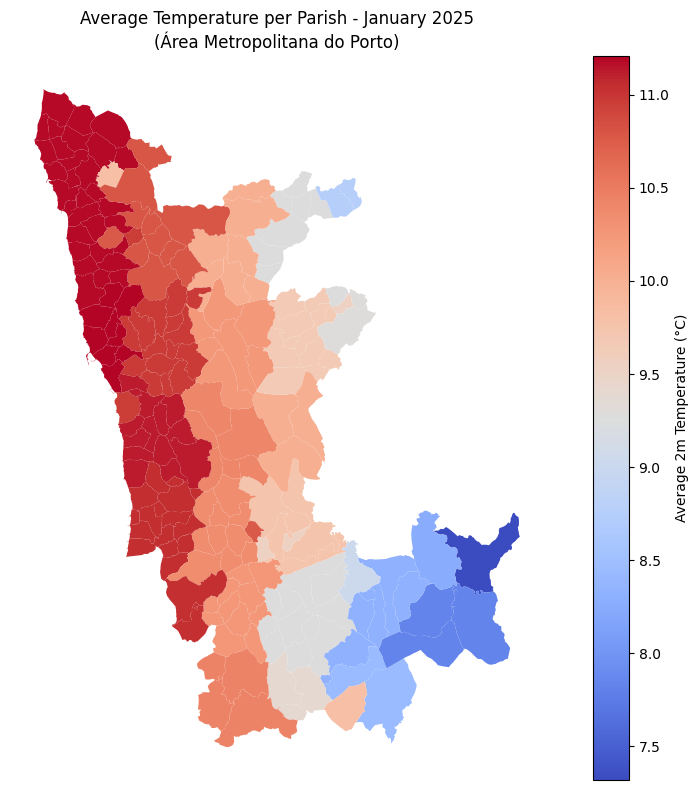

In [ ]:
# SECTION 1.2: Plot temperature maps average in January 2025

ds_jan_avg = ds[['t2m']].sel(valid_time=slice('2025-01-01', '2025-01-31')).mean(dim='valid_time')
df_jan = ds_jan_avg.to_dataframe().reset_index()

df_jan['t2m'] = pd.to_numeric(df_jan['t2m'], errors='coerce') - 273.15
df_jan = df_jan.dropna(subset=['t2m', 'longitude', 'latitude'])

if df_jan['longitude'].max() > 180:
    df_jan['longitude'] = df_jan['longitude'].apply(lambda x: x - 360 if x > 180 else x)

gdf_jan = gpd.GeoDataFrame(
    df_jan, 
    geometry=gpd.points_from_xy(df_jan['longitude'], df_jan['latitude']), 
    crs="EPSG:4326"
).to_crs("EPSG:3763")

porto_regions = regions[regions['nuts3'] == 'Área Metropolitana do Porto']
merged_gdf_jan = gpd.sjoin_nearest(porto_regions, gdf_jan, how="left")
map_data_jan = merged_gdf_jan.dissolve(by='freguesia', aggfunc={'t2m': 'mean'}).reset_index()

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

map_data_jan.plot(
    column='t2m', 
    ax=ax, 
    legend=True, 
    cmap='coolwarm', 
    missing_kwds={'color': 'lightgrey'}, 
    legend_kwds={'label': "Average 2m Temperature (°C)"}
)

ax.set_title("Average Temperature per Parish - January 2025\n(Área Metropolitana do Porto)")
ax.axis('off')

plt.tight_layout()
plt.show()

In [23]:
# SECTION 2: Full Data Processing Pipeline

import geopandas as gpd
import pandas as pd
import xarray as xr
import glob
import numpy as np
import gc


# STEP 1: Load Administrative Regions (AMP)

print("Loading Portuguese administrative regions...")
regions = gpd.read_file(
    "environment_input/Continente_CAOP2025.gpkg",
    layer="cont_freguesias"
).to_crs("EPSG:4326")

regions = regions[regions['nuts3'] == 'Área Metropolitana do Porto'].copy()
print(f"Loaded {len(regions)} parishes in Porto Metropolitan Area")


# STEP 2: Find NetCDF Files

file_pattern = "environment_input/era5_land_202*_Q*.nc"
nc_files = sorted(glob.glob(file_pattern))
print(f"Found {len(nc_files)} ERA5-Land files")

if not nc_files:
    raise ValueError("No NetCDF files found matching pattern: " + file_pattern)


# STEP 3: Build Spatial Lookup Table

print("Building ERA5 grid lookup table...")

# Load first file to get grid structure
ds_grid = xr.open_dataset(nc_files[0])
time_col = 'time' if 'time' in ds_grid.coords else 'valid_time'
first_step = ds_grid['t2m'].isel({time_col: 0})
df_coords = first_step.to_dataframe().reset_index()

# Extract valid (non-ocean) points
df_coords = df_coords.dropna(subset=['t2m'])[['longitude', 'latitude']]

# Standardize longitude (0-360 → -180-180)
df_coords["longitude_raw"] = df_coords["longitude"]
df_coords["longitude"] = np.where(
    df_coords["longitude_raw"] > 180,
    df_coords["longitude_raw"] - 360,
    df_coords["longitude_raw"]
)

# Round for safe merging
df_coords["longitude"] = df_coords["longitude"].round(4)
df_coords["latitude"] = df_coords["latitude"].round(4)

# Create spatial index
gdf_coords = gpd.GeoDataFrame(
    df_coords,
    geometry=gpd.points_from_xy(df_coords["longitude"], df_coords["latitude"]),
    crs="EPSG:4326"
).to_crs("EPSG:3763")

regions_proj = regions.to_crs("EPSG:3763")

# Map parishes to nearest valid ERA5 grid points
print("Assigning parishes to nearest ERA5 grid points...")
merged_coords = gpd.sjoin_nearest(
    regions_proj[['freguesia', 'municipio', 'nuts3', 'dtmnfr', 'geometry']],
    gdf_coords,
    how="left"
)

lookup_table = merged_coords[
    ['longitude', 'latitude', 'freguesia', 'municipio', 'nuts3', 'dtmnfr']
].drop_duplicates().rename(columns={'dtmnfr': 'parish_code'})

print(f"Created lookup table with {len(lookup_table)} parish-to-grid mappings")


# STEP 4: Define Bounding Box

# Add buffer to ensure edge parishes aren't excluded
buffer = 0.2
min_lon_nc = lookup_table['longitude'].min() - buffer
max_lon_nc = lookup_table['longitude'].max() + buffer
min_lat_nc = lookup_table['latitude'].min() - buffer
max_lat_nc = lookup_table['latitude'].max() + buffer

ds_grid.close()


# STEP 5: Process All NetCDF Files

print(f"\nProcessing {len(nc_files)} ERA5-Land files...")
monthly_dfs = []

for idx, file in enumerate(nc_files):
    print(f"[{idx+1}/{len(nc_files)}] {file.split('/')[-1]}", end=" → ")
    
    try:
        ds = xr.open_dataset(file)
        time_col = 'time' if 'time' in ds.coords else 'valid_time'

        # Standardize longitude
        ds = ds.assign_coords(longitude=(((ds.longitude + 180) % 360) - 180))
        ds = ds.sortby("longitude")

        # Handle latitude direction dynamically
        lat_values = ds.latitude.values
        if lat_values[0] > lat_values[-1]:
            lat_slice = slice(max_lat_nc, min_lat_nc)
        else:
            lat_slice = slice(min_lat_nc, max_lat_nc)

        # Crop to bounding box
        ds_subset = ds.sel(longitude=slice(min_lon_nc, max_lon_nc), latitude=lat_slice)
        df_env = ds_subset.to_dataframe().reset_index()

        # Extract required columns
        required_cols = [time_col, 'longitude', 'latitude', 't2m', 'tp']
        df_env = df_env[required_cols].dropna(subset=['longitude', 'latitude', 't2m', 'tp'])

        # Round for precise lookup matching
        df_env['longitude'] = df_env['longitude'].round(4)
        df_env['latitude'] = df_env['latitude'].round(4)

        # Merge with parish lookup
        df_merged = pd.merge(df_env, lookup_table, on=['longitude', 'latitude'], how='inner')

        if df_merged.empty:
            print("WARNING: Empty merge")
            ds.close()
            continue

        # Convert temperature (K → °C) and standardize dates
        df_merged['t2m'] = df_merged['t2m'] - 273.15
        df_merged = df_merged.rename(columns={time_col: 'datetime'})
        df_merged['datetime'] = pd.to_datetime(df_merged['datetime'])
        df_merged['year_month'] = df_merged['datetime'].dt.to_period('M')

        # Aggregate to monthly level
        df_monthly = (
            df_merged.groupby(['nuts3', 'municipio', 'freguesia', 'parish_code', 'year_month'])[['t2m', 'tp']]
            .mean()
            .reset_index()
        )
        
        monthly_dfs.append(df_monthly)
        print(f"{len(df_monthly):,} rows")

        # Cleanup
        ds.close()
        del ds, ds_subset, df_env, df_merged, df_monthly
        gc.collect()

    except Exception as e:
        print(f"ERROR: {e}")


# STEP 6: Combine & Save Output

print("\nCombining all monthly datasets...")
if not monthly_dfs:
    raise ValueError("No valid monthly data was generated")

amp_env_monthly = pd.concat(monthly_dfs, ignore_index=True)

# Remove duplicates in case months overlap across files
amp_env_monthly = (
    amp_env_monthly.groupby(['nuts3', 'municipio', 'freguesia', 'parish_code', 'year_month'])[['t2m', 'tp']]
    .mean()
    .reset_index()
)

print(f"Final dataset: {len(amp_env_monthly)} monthly records")

# Save output
output_file = "2_EnvironmentalData_output/month_env_region_AMP.csv"
amp_env_monthly.to_csv(output_file, index=False)
print(f"\nSuccessfully saved: {output_file}")

Loading Portuguese administrative regions...
Loaded 208 parishes in Porto Metropolitan Area
Found 24 ERA5-Land files
Building ERA5 grid lookup table...
Assigning parishes to nearest ERA5 grid points...
Created lookup table with 208 parish-to-grid mappings

Processing 24 ERA5-Land files...
[1/24] environment_input\era5_land_2020_Q1.nc → 624 rows
[2/24] environment_input\era5_land_2020_Q2.nc → 624 rows
[3/24] environment_input\era5_land_2020_Q3.nc → 624 rows
[4/24] environment_input\era5_land_2020_Q4.nc → 624 rows
[5/24] environment_input\era5_land_2021_Q1.nc → 624 rows
[6/24] environment_input\era5_land_2021_Q2.nc → 624 rows
[7/24] environment_input\era5_land_2021_Q3.nc → 624 rows
[8/24] environment_input\era5_land_2021_Q4.nc → 624 rows
[9/24] environment_input\era5_land_2022_Q1.nc → 624 rows
[10/24] environment_input\era5_land_2022_Q2.nc → 624 rows
[11/24] environment_input\era5_land_2022_Q3.nc → 624 rows
[12/24] environment_input\era5_land_2022_Q4.nc → 624 rows
[13/24] environment_inp